C:\Users\alok rana\AppData\Local\Temp\ipykernel_17296\3801497592.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('lab_sensor.csv',parse_dates=['timestamp'],index_col='timestamp')


                     reading
timestamp                   
2001-05-24 00:00:00     22.5
2001-05-24 01:00:00     23.1
2001-05-24 02:00:00     22.8
2001-05-24 03:00:00     24.0
2001-05-24 04:00:00     24.3
ADF p-value: 1.7032467395735514e-05
Data is stationary


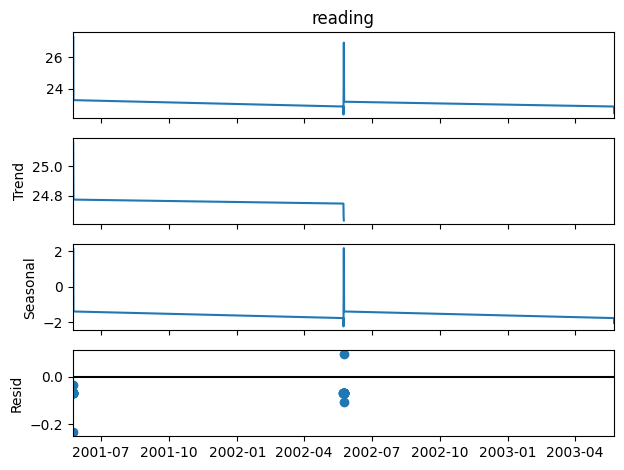

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


# STEP 1: Load Dataset

df = pd.read_csv('lab_sensor.csv',parse_dates=['timestamp'],index_col='timestamp')

print(df.head())


# STEP 2: Stationarity Test

adf_res = adfuller(df['reading'])

print("ADF p-value:", adf_res[1])

if adf_res[1] > 0.05:
    print("Trend or seasonality exists")
else:
    print("Data is stationary")


# STEP 3: Time Series Decomposition


decomp = seasonal_decompose(
    df['reading'],
    model='additive',
    period=24
)


# STEP 4: Visualization

decomp.plot()
plt.show()